<a href="https://colab.research.google.com/github/rambhatladvaith/Spice-classification-project/blob/main/Spice_classification_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- Section 1: Setup and Imports ---

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import pathlib
import os

# TensorFlow and Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# For file handling and extraction
from google.colab import files # For uploading files in Colab
#import zipfile
# Add this to your imports in Section 1 if not already there
from google.colab import files
from PIL import Image
import io

# Check TensorFlow and GPU availability (Optional but good practice)
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

TensorFlow version: 2.18.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 14583909172334052707
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 14619377664
locality {
  bus_id: 1
  links {
  }
}
incarnation: 12324525867580938765
physical_device_desc: "device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5"
xla_global_id: 416903419
]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# --- Section 2: Define and Verify Dataset Directory (Google Drive) ---

# Define the path to your dataset directory in Google Drive
# This is the folder containing your class subdirectories
dataset_dir = '/content/drive/My Drive/spiceclassification'

# Verify the dataset directory exists
print(f"\nChecking if dataset directory exists: {dataset_dir}")
if not os.path.exists(dataset_dir):
    print(f" Error: Dataset directory not found at {dataset_dir}.")
    print("Please ensure the path is correct and Google Drive is mounted.")
    dataset_is_ready = False # Flag to prevent data loading
    # You might want to stop execution here if the directory is not found
    # exit() # Uncomment to stop execution
elif not os.path.isdir(dataset_dir):
     print(f" Error: Dataset path {dataset_dir} is not a directory.")
     dataset_is_ready = False # Flag to prevent data loading
     # exit() # Uncomment to stop execution
else:
    print(f" Dataset directory found at {dataset_dir}")
    print("Checking for subdirectories (class folders) in the dataset_dir:")
    subdirs = [d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d)) and not d.startswith('.')]
    if subdirs:
        print(f"Found {len(subdirs)} subdirectories: {subdirs}")
        print("Assuming these are your class folders. Proceeding with data loading.")
        dataset_is_ready = True # Flag to indicate data loading can proceed
    else:
        print(" No subdirectories (class folders) found in the dataset directory.")
        print(f"Please ensure your class folders are directly inside {dataset_dir}.")
        dataset_is_ready = False # Flag to prevent data loading
        # Exit or raise an error if no class folders are found
        # exit() # Uncomment to stop execution if no class folders are found


Checking if dataset directory exists: /content/drive/My Drive/spiceclassification
 Dataset directory found at /content/drive/My Drive/spiceclassification
Checking for subdirectories (class folders) in the dataset_dir:
Found 8 subdirectories: ['clove', 'cardamom (elaichi)', 'star anise', 'Turmeric sticks', 'Cumin-Jeera', 'Bay leaf', 'Black pepper', 'cinnamon']
Assuming these are your class folders. Proceeding with data loading.


In [ ]:


if 'dataset_dir' in locals() and os.path.exists(dataset_dir):
  print("\nChecking for valid image files per class:")
  valid_image_counts = {}
  supported_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.gif', '.HEIC'] # Add other extensions if needed

  subdirs = [d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d)) and not d.startswith('.')]
  if subdirs:
    for class_name in subdirs:
      class_path = os.path.join(dataset_dir, class_name)
      num_valid_images = 0
      for filename in os.listdir(class_path):
          if os.path.splitext(filename)[1].lower() in supported_extensions:
              num_valid_images += 1
      valid_image_counts[class_name] = num_valid_images
      print(f"Class '{class_name}': {num_valid_images} valid images found")
  else:
    print("No subdirectories found in dataset_dir for valid image counting.")
else:
  print("Cannot check valid image distribution: dataset_dir not found.")


Checking for valid image files per class:
Class 'clove': 1096 valid images found
Class 'cardamom (elaichi)': 1008 valid images found
Class 'star anise': 1003 valid images found
Class 'Turmeric sticks': 1003 valid images found
Class 'Cumin-Jeera': 1210 valid images found
Class 'Bay leaf': 999 valid images found
Class 'Black pepper': 1005 valid images found
Class 'cinnamon': 1001 valid images found


In [ ]:

if 'dataset_dir' in locals() and os.path.exists(dataset_dir):
  print("\nChecking data distribution per class:")
  class_counts = {}
  subdirs = [d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d)) and not d.startswith('.')]
  if subdirs:
    for class_name in subdirs:
      class_path = os.path.join(dataset_dir, class_name)
      num_images = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
      class_counts[class_name] = num_images
      print(f"Class '{class_name}': {num_images} images")

            # Optional: Check if class_names from dataset loading match these subdirectories
    if 'class_names' in locals():
      print("\nClass names from image_dataset_from_directory:", class_names)
                 # You can compare class_counts keys with class_names to ensure they match
    else:
            print("No subdirectories found in dataset_dir for counting.")
else:
    print("Cannot check data distribution: dataset_dir not found.")


Checking data distribution per class:
Class 'clove': 1096 images
Class 'cardamom (elaichi)': 1008 images
Class 'star anise': 1003 images
Class 'Turmeric sticks': 1003 images
Class 'Cumin-Jeera': 1210 images
Class 'Bay leaf': 999 images
Class 'Black pepper': 1005 images
Class 'cinnamon': 1001 images

Class names from image_dataset_from_directory: ['Bay leaf', 'Black pepper', 'Cumin-Jeera', 'Turmeric sticks', 'cardamom (elaichi)', 'cinnamon', 'clove', 'star anise']


In [ ]:
# --- Section 3: Load Data using image_dataset_from_directory ---

# This is the recommended way to load image data from a directory structure
# where subdirectories represent classes. It handles splitting, batching,
# and resizing efficiently.

if dataset_is_ready:
    print("\nLoading data using keras.utils.image_dataset_from_directory...")

    # Define image dimensions expected by the model
    IMG_HEIGHT = 256
    IMG_WIDTH = 256
    BATCH_SIZE = 32

    train_data = keras.utils.image_dataset_from_directory(
        dataset_dir,
        validation_split=0.6, # Sets aside 40% of data for validation
        subset='training',
        seed=1, # Use a fixed seed for reproducible splits
        shuffle=True, # Shuffle the training data
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE
    )

    # The 'validation' subset here refers to the portion set aside by validation_split
    validation_data = keras.utils.image_dataset_from_directory(
        dataset_dir,
        validation_split=0.4,
        subset='validation',
        seed=1, # Use the same seed as training split
        shuffle=True, # No need to shuffle validation data usually
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE
    )

    # Keras automatically infers class names from subdirectory names
    class_names = train_data.class_names
    num_classes = len(class_names)

    print("\nClass names inferred from directories:", class_names)
    print(f"Number of classes: {num_classes}")
    print("Train data cardinality (number of batches):", train_data.cardinality().numpy())
    print("Validation data cardinality (number of batches):", validation_data.cardinality().numpy())


    # Let's rename validation_data to test_data for consistency with earlier code if needed for evaluation plots
    # But keep in mind it's the *validation* split from the original data.
    test_data_for_eval = validation_data
    print("Using validation split as 'test_data' for evaluation/plotting.")

else:
    print("Skipping data loading: Dataset directory not ready.")



Loading data using keras.utils.image_dataset_from_directory...
Found 8325 files belonging to 8 classes.
Using 3330 files for training.
Found 8325 files belonging to 8 classes.
Using 3330 files for validation.

Class names inferred from directories: ['Bay leaf', 'Black pepper', 'Cumin-Jeera', 'Turmeric sticks', 'cardamom (elaichi)', 'cinnamon', 'clove', 'star anise']
Number of classes: 8
Train data cardinality (number of batches): 105
Validation data cardinality (number of batches): 105
Using validation split as 'test_data' for evaluation/plotting.


In [ ]:
# Add this after Section 5
print("\nInspecting a batch from train_data:")
for images, labels in train_data.take(1): # Take one batch
  print("Batch image shape:", images.shape)
  print("Batch labels:", labels.numpy()) # Print the labels in this batch

print("\nInspecting a batch from validation_data:")
for images, labels in validation_data.take(1): # Take one batch
  print("Batch image shape:", images.shape)
  print("Batch labels:", labels.numpy()) # Print the labels in this batch


Inspecting a batch from train_data:
Batch image shape: (32, 256, 256, 3)
Batch labels: [1 6 6 0 1 2 0 3 5 6 1 0 0 2 5 5 2 1 5 4 5 0 5 2 1 5 7 4 5 6 1 5]

Inspecting a batch from validation_data:
Batch image shape: (32, 256, 256, 3)
Batch labels: [5 4 2 0 1 1 7 6 4 7 5 0 2 7 3 0 1 3 1 5 7 5 4 7 2 7 0 5 0 7 5 6]


In [ ]:
# --- Section 4: Build the CNN Model ---

# Define and compile the Convolutional Neural Network model.

if 'num_classes' in locals() and num_classes > 0:
    print("\nBuilding CNN model...")

    cnn_model = keras.Sequential([
        # Rescale pixel values from [0, 255] to [0, 1]
        layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        layers.Conv2D(filters=32, kernel_size=3, activation='relu'),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(filters=64, kernel_size=3, activation='relu'), # Added another Conv layer
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(filters=128, kernel_size=3, activation='relu'), # Added another Conv layer
        layers.MaxPooling2D(pool_size=2),
        layers.Flatten(),
        layers.Dense(500, activation='relu'),
        layers.Dense(num_classes, activation='softmax') # Output layer with softmax for multi-class classification
    ])

    # Compile the model
    # Using SparseCategoricalCrossentropy because labels are integers (0, 1, 2...)
    # and the output layer uses softmax probabilities.
    cnn_model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(),
        optimizer=keras.optimizers.Adam(),
        metrics=['accuracy']
    )

    cnn_model.summary()

else:
    print("Skipping model building: Number of classes not determined (dataset not loaded).")



Building CNN model...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 500)            │    57,600,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         4,008 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,697,756 (220.10 MB)

 Trainable params: 57,697,756 (220.10 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --- Section 5: Train the Model ---

# Train the compiled model using the loaded training and validation data.

if 'cnn_model' in locals() and 'train_data' in locals() and 'validation_data' in locals():
    print("\nStarting model training...")
    EPOCHS = 5 # Define number of training epochs

    # Use validation_data for monitoring performance during training
    history = cnn_model.fit(
        train_data,
        validation_data=validation_data, # Monitor performance on the validation set
        epochs=EPOCHS
    )
    print("Training finished.")

else:
    print("Skipping training: Model or data not ready.")


Starting model training...
Epoch 1/3
105/105 ━━━━━━━━━━━━━━━━━━━━ 1173s 11s/step - accuracy: 0.5045 - loss: 1.8685 - val_accuracy: 0.9480 - val_loss: 0.1587
Epoch 2/3
105/105 ━━━━━━━━━━━━━━━━━━━━ 1181s 11s/step - accuracy: 0.9635 - loss: 0.1231 - val_accuracy: 0.9631 - val_loss: 0.0982
Epoch 3/3
105/105 ━━━━━━━━━━━━━━━━━━━━ 1213s 11s/step - accuracy: 0.9730 - loss: 0.1002 - val_accuracy: 0.9571 - val_loss: 0.1484
Training finished.



Plotting training history...


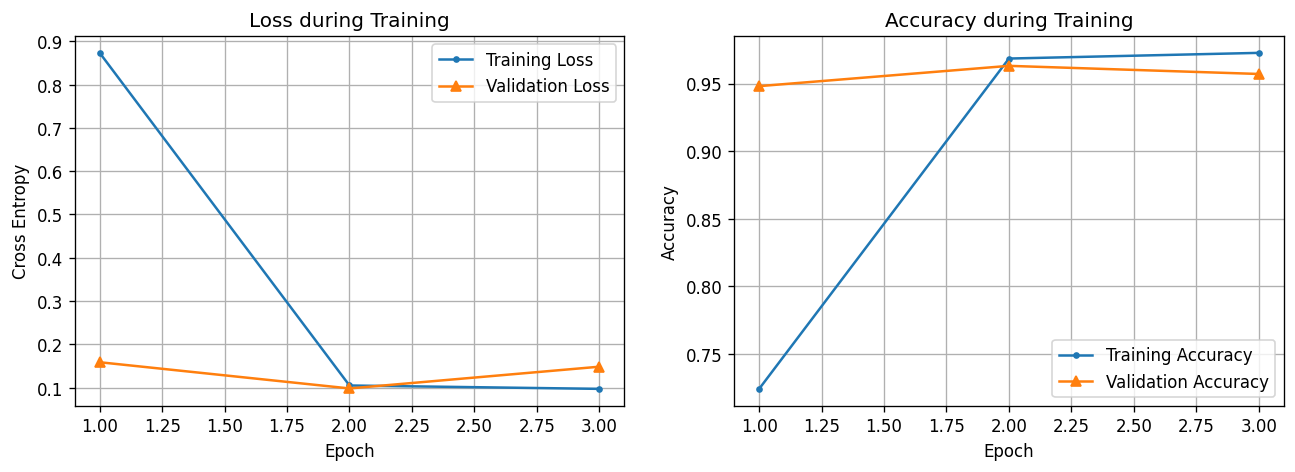

In [ ]:
# --- Section 6: Visualize Training History ---

# Plot training and validation accuracy and loss over epochs.

if 'history' in locals():
    print("\nPlotting training history...")

    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(13, 4), dpi=120)
    ax = plt.subplot(1, 2, 1)
    plt.plot(range(1, len(history_df) + 1), history_df['loss'], marker='.', label='Training Loss')
    plt.plot(range(1, len(history_df) + 1), history_df['val_loss'], marker='^', label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Cross Entropy')
    plt.title('Loss during Training')
    plt.grid()
    plt.legend()

    ax = plt.subplot(1, 2, 2)
    plt.plot(range(1, len(history_df) + 1), history_df['accuracy'], marker='.', label='Training Accuracy')
    plt.plot(range(1, len(history_df) + 1), history_df['val_accuracy'], marker='^', label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy during Training')
    plt.grid()
    plt.legend()

    plt.show()
else:
     print("Skipping plotting: Training history not available.")


Evaluating model on the validation set (used as test set for evaluation)...
105/105 ━━━━━━━━━━━━━━━━━━━━ 351s 3s/step - accuracy: 0.9612 - loss: 0.1434
*****************************
Validation Loss: 0.1484
Validation Accuracy: 0.9571

Generating Classification Report and Confusion Matrix...
Making predictions...
105/105 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step

Classification Report:
                    precision    recall  f1-score   support

          Bay leaf       1.00      0.84      0.91       405
      Black pepper       0.94      1.00      0.97       405
       Cumin-Jeera       0.98      0.97      0.98       504
   Turmeric sticks       0.89      0.99      0.94       393
cardamom (elaichi)       1.00      1.00      1.00       383
          cinnamon       0.94      0.92      0.93       392
             clove       0.98      0.94      0.96       425
        star anise       0.95      1.00      0.97       423

          accuracy                           0.96      3330
         macro av

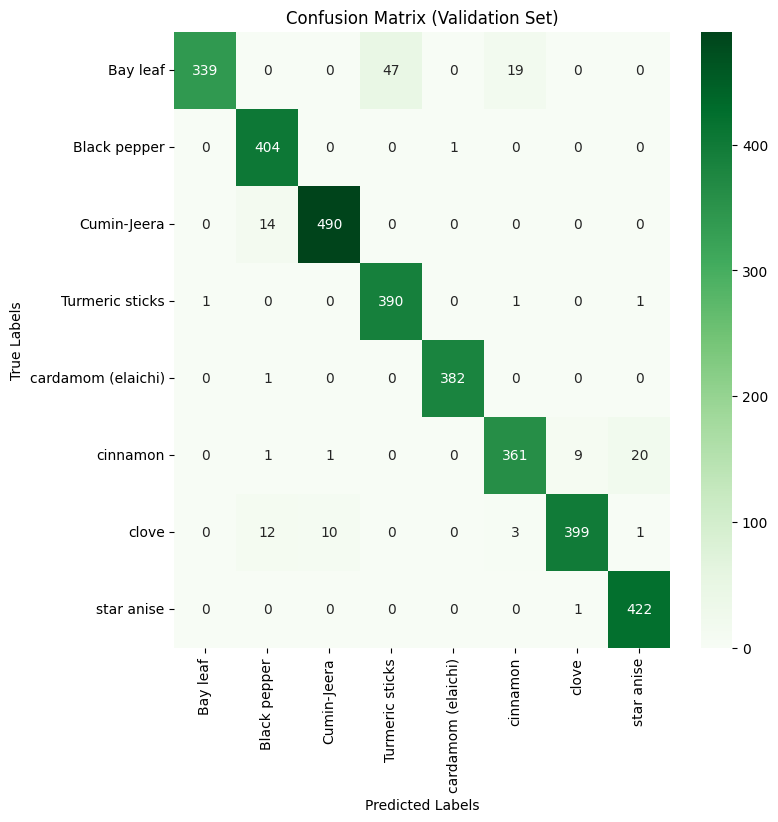

In [ ]:
# --- Section 7: Evaluate the Model ---

# Evaluate the model's performance on the test/validation set.

if 'cnn_model' in locals() and 'test_data_for_eval' in locals() and 'class_names' in locals(): # Ensure class_names is available
    print("\nEvaluating model on the validation set (used as test set for evaluation)...")

    # Evaluate using the tf.data.Dataset directly for efficiency
    evaluation_score = cnn_model.evaluate(test_data_for_eval, verbose=1)
    print('*****************************')
    print(f"Validation Loss: {evaluation_score[0]:.4f}")
    print(f"Validation Accuracy: {evaluation_score[1]:.4f}")

    # For more detailed metrics like Classification Report and Confusion Matrix,
    # we need to get predictions and true labels for the entire dataset.
    # This can be memory intensive for large datasets.

    print("\nGenerating Classification Report and Confusion Matrix...")

    # Collect all images and labels from the validation dataset
    # Note: This can be slow and memory-intensive.
    all_image_batches = []
    all_label_batches = []
    try:
        for images, labels in test_data_for_eval:
            all_image_batches.append(images)
            all_label_batches.append(labels)

        if all_image_batches:
            # Concatenate batches into single tensors
            all_images = tf.concat(all_image_batches, axis=0)
            all_labels = tf.concat(all_label_batches, axis=0)

            # Make predictions on the collected images
            print("Making predictions...")
            predictions_proba = cnn_model.predict(all_images)
            predicted_labels = np.argmax(predictions_proba, axis=1) # Get class index

            # Ensure true labels are in numpy format
            true_labels_np = all_labels.numpy()

            # Classification Report
            from sklearn.metrics import classification_report
            print("\nClassification Report:")

            # Get the unique true labels present in the validation data
            unique_true_labels = np.unique(true_labels_np)

            # Filter class_names to match the unique true labels
            # This is important for the labels parameter and target_names to align
            filtered_class_names = [class_names[i] for i in unique_true_labels]


            # Use the correct target names (class_names from the dataset)
            # Pass the unique true labels to the 'labels' parameter
            print(classification_report(true_labels_np, predicted_labels,
                                        target_names=filtered_class_names, # Use filtered class names for target_names
                                        labels=unique_true_labels)) # Specify the labels to consider

            # Confusion Matrix
            from sklearn.metrics import confusion_matrix
            import seaborn as sns

            # Use the full range of possible class indices for the confusion matrix
            # This assumes class_names is correctly ordered based on the directory structure
            # which image_dataset_from_directory usually ensures.
            all_class_indices = list(range(len(class_names)))

            cm = confusion_matrix(true_labels_np, predicted_labels, labels=all_class_indices)

            plt.figure(figsize=(8, 8), dpi=100)
            # Use the full class names for the heatmap ticks
            sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
            plt.xlabel('Predicted Labels')
            plt.ylabel('True Labels')
            plt.title('Confusion Matrix (Validation Set)')
            plt.show()

        else:
            print("No images found in the validation dataset to generate detailed report/matrix.")

    except Exception as e:
         print(f"An error occurred while generating classification report/confusion matrix: {e}")
         print("This might be due to memory issues with a large dataset.")

else:
     print("Skipping evaluation: Model or evaluation data not ready.")


Plotting Random Images with Predictions from Validation Set:
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


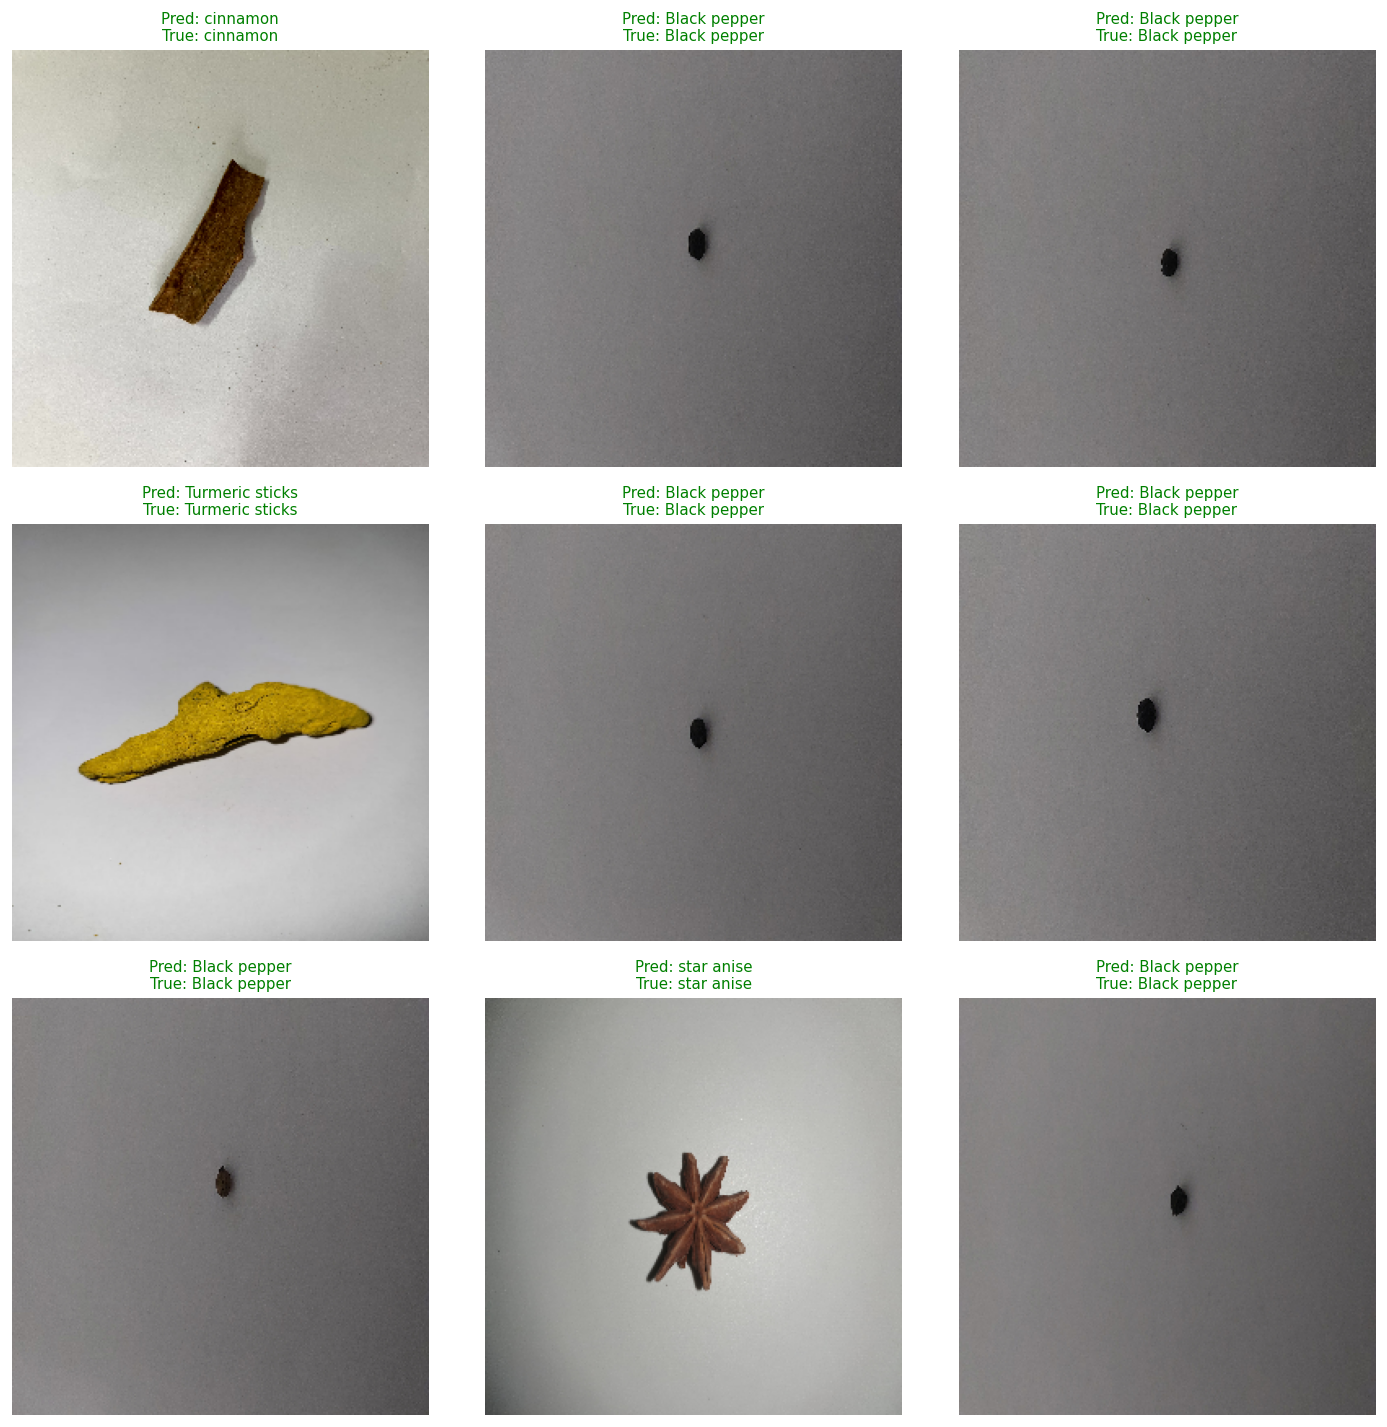

In [ ]:
# --- Section 8: Plot Random Images with Predictions ---

# Visualize some random images from the validation set with their true and predicted labels.

if 'cnn_model' in locals() and 'test_data_for_eval' in locals() and 'class_names' in locals():
    print("\nPlotting Random Images with Predictions from Validation Set:")

    def plot_random_images_with_predictions(dataset, model, num_images=9):
        """
        Plots random images from a dataset batch and displays their true labels
        and model predictions using the dataset's class names.

        Args:
            dataset: A TensorFlow dataset object (e.g., validation_data).
                     Assumes the dataset provides (images, labels) batches.
            model: A trained Keras model.
            num_images: The number of random images to plot from a batch.
        """
        # Check if the dataset has any elements
        if dataset.cardinality().numpy() == 0:
            print("Cannot plot images: Dataset is empty.")
            return

        try:
            # Take one batch from the dataset
            # Use .take(1) to get a single batch to avoid iterating the whole dataset
            for images, labels in dataset.take(1):
                # Make predictions for the images in this batch
                predictions_proba = model.predict(images)
                predicted_labels = np.argmax(predictions_proba, axis=1) # Get the index of the max probability

                plt.figure(figsize=(12, 12), dpi=120)

                # Select random indices from the current batch
                # Ensure we don't request more images than available in the batch
                indices = random.sample(range(images.shape[0]), min(num_images, images.shape[0]))

                for i, index in enumerate(indices):
                    ax = plt.subplot(int(np.ceil(num_images/3)), 3, i + 1)

                    # Get the image and true label
                    img = images[index].numpy().astype("uint8")
                    # Labels from image_dataset_from_directory are integers
                    true_label = class_names[labels[index].numpy()]
                    predicted_label = class_names[predicted_labels[index]]

                    # Determine text color based on correctness
                    color = 'g' if predicted_label == true_label else 'r'

                    plt.imshow(img)
                    plt.title(f'Pred: {predicted_label}\nTrue: {true_label}', color=color, fontsize=9)
                    plt.axis(False)

                plt.tight_layout()
                plt.show()
                break # Process only one batch

        except Exception as e:
            print(f"An error occurred while plotting random images: {e}")


    # Plot random images and predictions from the validation dataset
    plot_random_images_with_predictions(test_data_for_eval, cnn_model, num_images=9)

else:
     print("Skipping plotting random images: Model, data, or class names not ready.")


Ready to predict on a single uploaded image.


Saving IMG_1065.jpg to IMG_1065.jpg
User uploaded file "IMG_1065.jpg"
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

Prediction for 'IMG_1065.jpg':
Predicted Spice: cinnamon
Confidence: 98.36%


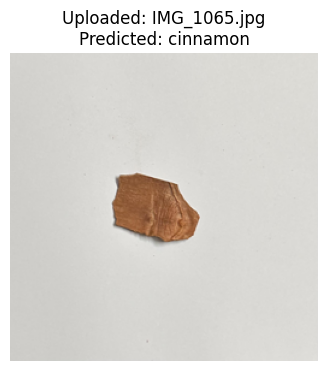

In [ ]:
# --- Section 9: Predict on a Single Uploaded Image ---

print("\nReady to predict on a single uploaded image.")

if 'cnn_model' in locals() and 'class_names' in locals() and 'IMG_HEIGHT' in locals() and 'IMG_WIDTH' in locals():

    uploaded = files.upload()

    for fn in uploaded.keys():
        print(f'User uploaded file "{fn}"')

        # Read the image file
        img_bytes = uploaded[fn]
        img_io = io.BytesIO(img_bytes)

        try:
            # Open and resize the image
            img = Image.open(img_io)

            # Ensure image is in RGB format (some images might be grayscale, etc.)
            if img.mode != 'RGB':
                img = img.convert('RGB')

            img = img.resize((IMG_WIDTH, IMG_HEIGHT)) # Resize to model's input size
            img_array = np.array(img) # Convert to NumPy array

            # Add a batch dimension (model expects batches)
            img_array = tf.expand_dims(img_array, 0) # Shape becomes (1, IMG_HEIGHT, IMG_WIDTH, 3)

            # Make prediction
            predictions = cnn_model.predict(img_array)

            # Get the predicted class index (highest probability)
            predicted_class_index = np.argmax(predictions, axis=1)[0]

            # Get the predicted class name
            predicted_class_name = class_names[predicted_class_index]

            # Get the confidence score (probability of the predicted class)
            confidence = np.max(predictions) * 100

            print(f"\nPrediction for '{fn}':")
            print(f"Predicted Spice: {predicted_class_name}")
            print(f"Confidence: {confidence:.2f}%")

            # Optional: Display the uploaded image
            plt.figure(figsize=(4, 4))
            plt.imshow(img)
            plt.title(f"Uploaded: {fn}\nPredicted: {predicted_class_name}")
            plt.axis("off")
            plt.show()


        except Exception as e:
            print(f"Error processing image '{fn}': {e}")

else:
    print("Skipping single image prediction: Model, class names, or image dimensions not available.")